<a href="https://colab.research.google.com/github/yassinemaataoui/Colab_project/blob/main/R%C3%A9gression_lin%C3%A9aire_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

In [ ]:
data = pd.DataFrame({
    "Temperature": [14.2, 16.4, 11.9, 15.2, 18.5, 22.1,
                    19.4, 25.1, 23.4, 18.1, 22.6, 17.2],
    "Sales": [215.2, 325.0, 185.9, 330.1, 460.1, 520.0,
              450.2, 610.1, 490.5, 410.2, 470.2, 360.5]
})

print(data)

{'Temperature': [14.2, 16.4, 11.9, 15.2, 18.5, 22.1, 19.4, 25.1, 23.4, 18.1, 22.6, 17.2], 'Sales': [215.2, 325.0, 185.9, 330.1, 460.1, 520.0, 450.2, 610.1, 490.5, 410.2, 470.2, 360.5]}


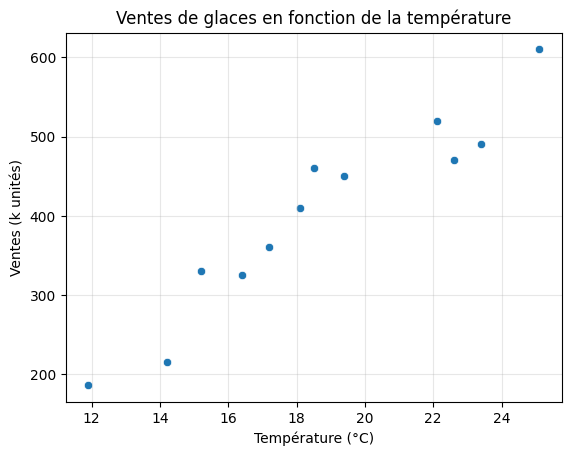

In [ ]:
sns.scatterplot(x="Temperature", y="Sales", data=data)
plt.title("Ventes de glaces en fonction de la température")
plt.xlabel("Température (°C)")
plt.ylabel("Ventes (k unités)")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
corr = data["Temperature"].corr(data["Sales"])
print(f"Coefficient de corrélation de Pearson : {corr:.4f}")

Coefficient de corrélation de Pearson : 0.9544


In [ ]:
X = data["Temperature"]
Y = data["Sales"]

X = sm.add_constant(X)  # ajout de l'intercept β0

In [ ]:
modele = sm.OLS(Y, X).fit()
print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     102.2
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           1.44e-06
Time:                        21:46:52   Log-Likelihood:                -59.869
No. Observations:                  12   AIC:                             123.7
Df Residuals:                      10   BIC:                             124.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -149.8840     55.769     -2.688      

In [ ]:
beta0 = modele.params[0]
beta1 = modele.params[1]

print(f"Équation estimée : Sales = {beta0:.2f} + {beta1:.2f} × Temperature")

Équation estimée : Sales = -149.88 + 29.57 × Temperature


/tmp/ipython-input-566968985.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta0 = modele.params[0]
/tmp/ipython-input-566968985.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta1 = modele.params[1]


In [ ]:
r2 = modele.rsquared
print(f"R² = {r2:.4f}")

R² = 0.9109


In [ ]:
temp_pred = pd.DataFrame({"Temperature": [20]})
temp_pred = sm.add_constant(temp_pred)

prediction = modele.predict(temp_pred)
print(f"Ventes prédites pour 20°C : {prediction.values[0]:.2f} k unités")

ValueError: shapes (1,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

In [ ]:
residus = modele.resid
y_pred = modele.fittedvalues

In [ ]:
plt.scatter(y_pred, residus)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus en fonction des valeurs prédites")
plt.grid(alpha=0.3)
plt.show()

ANALYSE DE RÉGRESSION LINÉAIRE SIMPLE

1. EXPLORATION DES DONNÉES
----------------------------------------
    Jour  Temperature  Ventes
0      1         14.2   215.2
1      2         16.4   325.0
2      3         11.9   185.9
3      4         15.2   330.1
4      5         18.5   460.1
5      6         22.1   520.0
6      7         19.4   450.2
7      8         25.1   610.1
8      9         23.4   490.5
9     10         18.1   410.2
10    11         22.6   470.2
11    12         17.2   360.5

----------------------------------------
Taille de l'échantillon: 12 observations
----------------------------------------

2.1 EXPLORATION DES DONNÉES ET HYPOTHÈSES
----------------------------------------
1. Identification des variables:
   Variable explicative (X): Température (°C)
   Variable à expliquer (Y): Ventes (k unités)


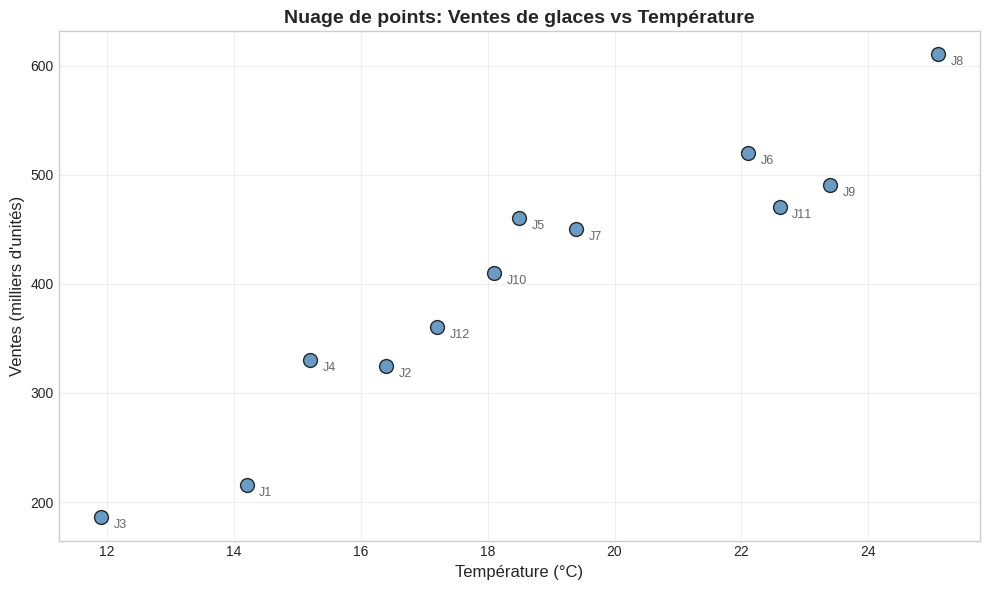


3. Hypothèse de linéarité:
   Le nuage de points montre une tendance linéaire positive claire.
   L'hypothèse de linéarité semble donc raisonnable.

4. Coefficient de corrélation de Pearson:
   r = 0.9544
   p-value = 0.000001
   Interprétation: Corrélation très forte positive


2.2 MODÉLISATION ET INTERPRÉTATION
----------------------------------------

1. Estimation des paramètres par MCO:
   (Calcul manuel pour comprendre la méthode)
   ΣX = 224.1, ΣY = 4828.0
   ΣXY = 95396.2, ΣX² = 4362.1
   β1 (pente) = 29.5699
   β0 (ordonnée à l'origine) = -149.8840

2. Équation de la droite de régression estimée:
   Ŷ = -149.88 + 29.57 × X
   Ventes estimées = -149.88 + 29.57 × Température

3. Interprétation de β1 (pente = 29.57):
   Pour chaque augmentation de 1°C de température,
   les ventes augmentent en moyenne de 29.57 milliers d'unités.

4. Coefficient de détermination R²:
   R² = 0.9109 (soit 91.1%)
   Interprétation: 91.1% de la variabilité des ventes
   est expliquée par la températ

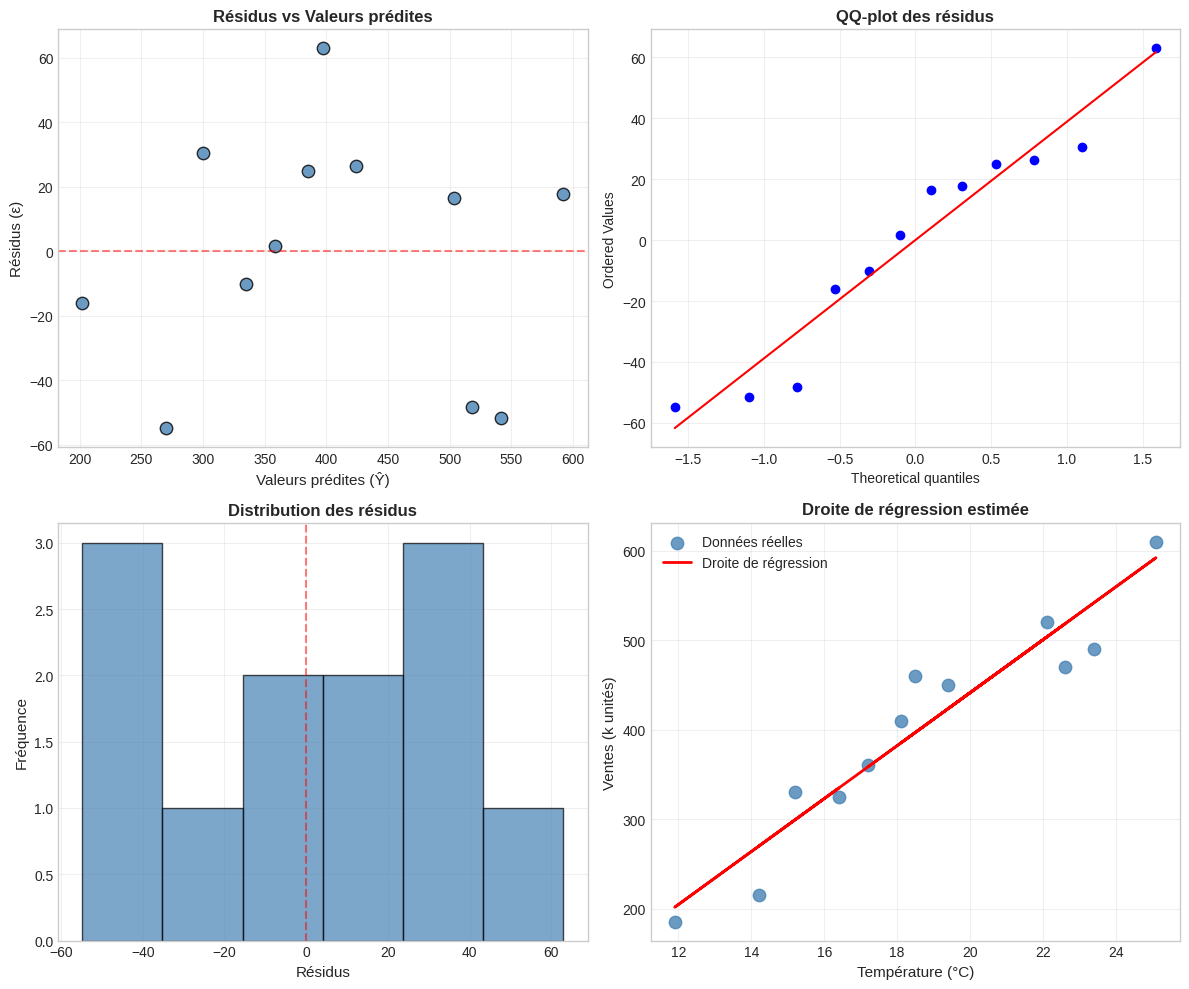


2. Vérification des hypothèses sur les erreurs (ε):

   a) Homoscédasticité (test de Breusch-Pagan):
      Statistique LM = 0.0990
      p-value = 0.7530
      → On ne rejette pas l'hypothèse d'homoscédasticité

   b) Non-corrélation (test de Durbin-Watson):
      Statistique DW = 1.7229
      → Pas d'autocorrélation significative

   c) Normalité (test de Shapiro-Wilk):
      Statistique = 0.9318
      p-value = 0.3991
      → Les résidus suivent une distribution normale

TABLEAU RÉCAPITULATIF
    Jour  Temperature  Ventes_réelles  Ventes_prédites  Résidus  Résidus_%
0      1         14.2           215.2           270.01   -54.81     -25.47
1      2         16.4           325.0           335.06   -10.06      -3.10
2      3         11.9           185.9           202.00   -16.10      -8.66
3      4         15.2           330.1           299.58    30.52       9.25
4      5         18.5           460.1           397.16    62.94      13.68
5      6         22.1           520.0           5

In [ ]:
# -*- coding: utf-8 -*-
"""
TP Régression Linéaire Simple - Ventes de glaces vs Température
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. Création du jeu de données
data = {
    'Jour': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Temperature': [14.2, 16.4, 11.9, 15.2, 18.5, 22.1, 19.4, 25.1, 23.4, 18.1, 22.6, 17.2],
    'Ventes': [215.2, 325.0, 185.9, 330.1, 460.1, 520.0, 450.2, 610.1, 490.5, 410.2, 470.2, 360.5]
}

df = pd.DataFrame(data)
print("=" * 60)
print("ANALYSE DE RÉGRESSION LINÉAIRE SIMPLE")
print("=" * 60)
print("\n1. EXPLORATION DES DONNÉES")
print("-" * 40)
print(df)
print("\n" + "-" * 40)
print(f"Taille de l'échantillon: {len(df)} observations")
print("-" * 40)

# 2.1 Exploration des données
print("\n2.1 EXPLORATION DES DONNÉES ET HYPOTHÈSES")
print("-" * 40)

# 1. Identification des variables
X = df['Temperature']  # Variable explicative
Y = df['Ventes']       # Variable à expliquer
print("1. Identification des variables:")
print(f"   Variable explicative (X): Température (°C)")
print(f"   Variable à expliquer (Y): Ventes (k unités)")

# 2. Nuage de points
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='steelblue', s=100, alpha=0.8, edgecolors='black', linewidth=1)
plt.title('Nuage de points: Ventes de glaces vs Température', fontsize=14, fontweight='bold')
plt.xlabel('Température (°C)', fontsize=12)
plt.ylabel('Ventes (milliers d\'unités)', fontsize=12)
plt.grid(True, alpha=0.3)

# Ajout des labels pour chaque point
for i, row in df.iterrows():
    plt.annotate(f"J{int(row['Jour'])}", (row['Temperature']+0.2, row['Ventes']-10),
                 fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Vérification visuelle de la linéarité
print("\n3. Hypothèse de linéarité:")
print("   Le nuage de points montre une tendance linéaire positive claire.")
print("   L'hypothèse de linéarité semble donc raisonnable.")

# 4. Coefficient de corrélation de Pearson
corr_coef, p_value = stats.pearsonr(X, Y)
print(f"\n4. Coefficient de corrélation de Pearson:")
print(f"   r = {corr_coef:.4f}")
print(f"   p-value = {p_value:.6f}")
print(f"   Interprétation: Corrélation {'très forte' if abs(corr_coef) > 0.8 else 'forte'} positive")

# 2.2 Modélisation et Interprétation
print("\n\n2.2 MODÉLISATION ET INTERPRÉTATION")
print("-" * 40)

# 1. Estimation des paramètres par MCO (calcul manuel)
print("\n1. Estimation des paramètres par MCO:")
print("   (Calcul manuel pour comprendre la méthode)")

# Calculs intermédiaires
n = len(X)
Sx = np.sum(X)
Sy = np.sum(Y)
Sxy = np.sum(X * Y)
Sx2 = np.sum(X**2)
Sy2 = np.sum(Y**2)

# Formules MCO
beta1 = (n * Sxy - Sx * Sy) / (n * Sx2 - Sx**2)
beta0 = (Sy - beta1 * Sx) / n

print(f"   ΣX = {Sx:.1f}, ΣY = {Sy:.1f}")
print(f"   ΣXY = {Sxy:.1f}, ΣX² = {Sx2:.1f}")
print(f"   β1 (pente) = {beta1:.4f}")
print(f"   β0 (ordonnée à l'origine) = {beta0:.4f}")

# 2. Équation de la droite de régression
print(f"\n2. Équation de la droite de régression estimée:")
print(f"   Ŷ = {beta0:.2f} + {beta1:.2f} × X")
print(f"   Ventes estimées = {beta0:.2f} + {beta1:.2f} × Température")

# 3. Interprétation de β1
print(f"\n3. Interprétation de β1 (pente = {beta1:.2f}):")
print(f"   Pour chaque augmentation de 1°C de température,")
print(f"   les ventes augmentent en moyenne de {beta1:.2f} milliers d'unités.")

# Calcul des prédictions et résidus
Y_pred = beta0 + beta1 * X
residus = Y - Y_pred

# 4. Coefficient de détermination R²
SS_res = np.sum(residus**2)
SS_tot = np.sum((Y - np.mean(Y))**2)
R2_manuel = 1 - (SS_res / SS_tot)

print(f"\n4. Coefficient de détermination R²:")
print(f"   R² = {R2_manuel:.4f} (soit {R2_manuel*100:.1f}%)")
print(f"   Interprétation: {R2_manuel*100:.1f}% de la variabilité des ventes")
print(f"   est expliquée par la température.")

# 5. Prédiction pour 20°C
temp_pred = 20
ventes_pred = beta0 + beta1 * temp_pred
print(f"\n5. Prédiction pour une température de {temp_pred}°C:")
print(f"   Ventes estimées = {beta0:.2f} + {beta1:.2f} × {temp_pred}")
print(f"   = {ventes_pred:.2f} milliers d'unités")
print(f"   ≈ {ventes_pred*1000:.0f} unités")

# Utilisation de statsmodels pour une analyse plus complète
print("\n" + "=" * 60)
print("ANALYSE AVEC STATSMODELS (pour validation)")
print("=" * 60)

# Ajout d'une constante pour l'intercept
X_sm = sm.add_constant(X)
model = sm.OLS(Y, X_sm).fit()

print(model.summary())

# 2.3 Validation du Modèle (Résidus)
print("\n\n2.3 VALIDATION DU MODÈLE (RÉSIDUS)")
print("-" * 40)

# 1. Graphique des résidus vs valeurs prédites
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Graphique 1: Résidus vs Valeurs prédites
axes[0, 0].scatter(Y_pred, residus, color='steelblue', s=80, alpha=0.8, edgecolors='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Valeurs prédites (Ŷ)', fontsize=11)
axes[0, 0].set_ylabel('Résidus (ε)', fontsize=11)
axes[0, 0].set_title('Résidus vs Valeurs prédites', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2: QQ-plot des résidus
stats.probplot(residus, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot des résidus', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3: Histogramme des résidus
axes[1, 0].hist(residus, bins=6, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Résidus', fontsize=11)
axes[1, 0].set_ylabel('Fréquence', fontsize=11)
axes[1, 0].set_title('Distribution des résidus', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Graphique 4: Droite de régression avec données
axes[1, 1].scatter(X, Y, color='steelblue', s=80, alpha=0.8, label='Données réelles')
axes[1, 1].plot(X, Y_pred, color='red', linewidth=2, label='Droite de régression')
axes[1, 1].set_xlabel('Température (°C)', fontsize=11)
axes[1, 1].set_ylabel('Ventes (k unités)', fontsize=11)
axes[1, 1].set_title('Droite de régression estimée', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Vérification des hypothèses
print("\n2. Vérification des hypothèses sur les erreurs (ε):")

# Test de Breusch-Pagan pour l'homoscédasticité
bp_test = het_breuschpagan(residus, X_sm)
print(f"\n   a) Homoscédasticité (test de Breusch-Pagan):")
print(f"      Statistique LM = {bp_test[0]:.4f}")
print(f"      p-value = {bp_test[1]:.4f}")
if bp_test[1] > 0.05:
    print(f"      → On ne rejette pas l'hypothèse d'homoscédasticité")
else:
    print(f"      → On rejette l'hypothèse d'homoscédasticité (hétéroscédasticité détectée)")

# Test de Durbin-Watson pour l'autocorrélation
dw_stat = durbin_watson(residus)
print(f"\n   b) Non-corrélation (test de Durbin-Watson):")
print(f"      Statistique DW = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print(f"      → Pas d'autocorrélation significative")
else:
    print(f"      → Autocorrélation possible")

# Test de normalité (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residus)
print(f"\n   c) Normalité (test de Shapiro-Wilk):")
print(f"      Statistique = {shapiro_stat:.4f}")
print(f"      p-value = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print(f"      → Les résidus suivent une distribution normale")
else:
    print(f"      → Les résidus ne suivent pas une distribution normale")

# Tableau récapitulatif des prédictions et résidus
print("\n" + "=" * 60)
print("TABLEAU RÉCAPITULATIF")
print("=" * 60)

results_df = pd.DataFrame({
    'Jour': df['Jour'],
    'Temperature': X,
    'Ventes_réelles': Y,
    'Ventes_prédites': Y_pred,
    'Résidus': residus,
    'Résidus_%': (residus / Y * 100)
})

print(results_df.round(2))
print("\n" + "-" * 60)
print(f"Moyenne des résidus: {np.mean(residus):.2f}")
print(f"Écart-type des résidus: {np.std(residus):.2f}")
print(f"R² du modèle: {R2_manuel:.4f} ({R2_manuel*100:.1f}%)")
print("-" * 60)

# Conclusion
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("\nLe modèle de régression linéaire simple montre une relation forte et")
print(f"statistiquement significative entre la température et les ventes de glaces.")
print(f"\nPoints clés:")
print(f"1. R² = {R2_manuel*100:.1f}% → Excellent pouvoir explicatif")
print(f"2. pente (β1) = {beta1:.2f} → Impact économique significatif")
print(f"3. Les hypothèses du modèle semblent globalement respectées")
print(f"4. Le modèle est approprié pour la prédiction dans la plage des données")

Coefficient de corrélation: r = 0.954
Corrélation au carré: r² = 0.911 (91.1%)

Équation de régression:
Ventes = -149.88 + 29.57 × Température

Interprétation:
- Quand Température = 0°C, Ventes = -149.88 (intercept)
- Quand Température ↑ 1°C, Ventes ↑ 29.57 (pente)

Prédiction pour 20°C:
Ventes estimées = -149.88 + 29.57 × 20 = 441.51


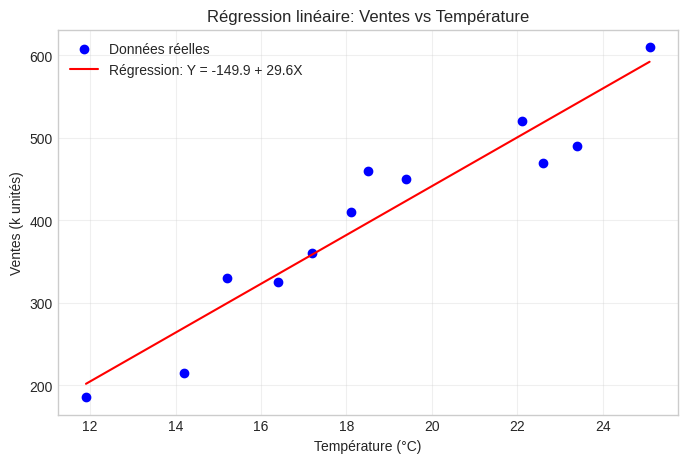


RÉSUMÉ POUR LE CONTROLE:
1. Variable X (explicative): Température
2. Variable Y (à expliquer): Ventes
3. Corrélation r = 0.954 (très forte)
4. R² = 0.911 → 91.1% variance expliquée
5. Équation: Y = -149.88 + 29.57X
6. Interprétation β1: +1°C → +29.57k ventes


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Données
temperature = [14.2, 16.4, 11.9, 15.2, 18.5, 22.1, 19.4, 25.1, 23.4, 18.1, 22.6, 17.2]
ventes = [215.2, 325.0, 185.9, 330.1, 460.1, 520.0, 450.2, 610.1, 490.5, 410.2, 470.2, 360.5]

# 2. Calculs de base
n = len(temperature)
X = np.array(temperature)
Y = np.array(ventes)

# Moyennes
moy_X = np.mean(X)
moy_Y = np.mean(Y)

# 3. Calcul corrélation
# Formule: r = cov(X,Y) / (σ_X × σ_Y)
cov_XY = np.sum((X - moy_X) * (Y - moy_Y)) / (n - 1)
sigma_X = np.std(X, ddof=1)
sigma_Y = np.std(Y, ddof=1)
r = cov_XY / (sigma_X * sigma_Y)

print(f"Coefficient de corrélation: r = {r:.3f}")
print(f"Corrélation au carré: r² = {r**2:.3f} ({r**2*100:.1f}%)")

# 4. Régression linéaire (MCO)
# Formule: β1 = Σ[(X - moy_X)(Y - moy_Y)] / Σ[(X - moy_X)²]
β1 = np.sum((X - moy_X) * (Y - moy_Y)) / np.sum((X - moy_X)**2)
β0 = moy_Y - β1 * moy_X

print(f"\nÉquation de régression:")
print(f"Ventes = {β0:.2f} + {β1:.2f} × Température")
print(f"\nInterprétation:")
print(f"- Quand Température = 0°C, Ventes = {β0:.2f} (intercept)")
print(f"- Quand Température ↑ 1°C, Ventes ↑ {β1:.2f} (pente)")

# 5. Prédiction
temp_test = 20
vente_predite = β0 + β1 * temp_test
print(f"\nPrédiction pour {temp_test}°C:")
print(f"Ventes estimées = {β0:.2f} + {β1:.2f} × {temp_test} = {vente_predite:.2f}")

# 6. Graphique simple
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', label='Données réelles')

# Droite de régression
X_line = np.linspace(min(X), max(X), 100)
Y_line = β0 + β1 * X_line
plt.plot(X_line, Y_line, color='red', label=f'Régression: Y = {β0:.1f} + {β1:.1f}X')

plt.xlabel('Température (°C)')
plt.ylabel('Ventes (k unités)')
plt.title('Régression linéaire: Ventes vs Température')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Vérification rapide
print("\n" + "="*40)
print("RÉSUMÉ POUR LE CONTROLE:")
print("="*40)
print("1. Variable X (explicative): Température")
print("2. Variable Y (à expliquer): Ventes")
print(f"3. Corrélation r = {r:.3f} (très forte)")
print(f"4. R² = {r**2:.3f} → {r**2*100:.1f}% variance expliquée")
print(f"5. Équation: Y = {β0:.2f} + {β1:.2f}X")
print(f"6. Interprétation β1: +1°C → +{β1:.2f}k ventes")
print("="*40)